In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load your stereo images (grayscale)
left_img = cv2.imread('left.png', cv2.IMREAD_GRAYSCALE)
right_img = cv2.imread('right.png', cv2.IMREAD_GRAYSCALE)

if left_img is None or right_img is None:
    raise FileNotFoundError("Left or Right image not found!")

# StereoSGBM parameters
min_disp = -2
num_disp = 16 * 1  # must be divisible by 16
block_size = 3

sgbm = cv2.StereoSGBM_create(
    minDisparity=min_disp,
    numDisparities=num_disp,
    blockSize=block_size,
    P1=8 * 3 * block_size ** 2,
    P2=32 * 3 * block_size ** 2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32
)

# Compute disparity
disp = sgbm.compute(left_img, right_img).astype(np.float32) / 16.0
disp_clean = cv2.medianBlur(disp, 5)

# Simulated camera intrinsics
fx = 525.0  # replace with real if known
baseline = 0.1  # 10 cm baseline

# Compute depth
depth = np.zeros(disp_clean.shape, np.float32)
valid = disp_clean > 0
depth[valid] = (fx * baseline) / disp_clean[valid]

# Plotting for visual debug
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title("Disparity")
plt.imshow(disp_clean, cmap='plasma')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Depth Map")
plt.imshow(depth, cmap='inferno')
plt.colorbar()

plt.show()


In [2]:
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import Image

import numpy as np
import threading

class DepthSaver(Node):
    def __init__(self):
        super().__init__('depth_saver')

        self.ros_depth = None
        # self.gz_depth = None
        self.lock = threading.Lock()

        self.create_subscription(
            Image,
            '/rgbd_cam/depth',
            self.ros_callback,
            10
        )

        # GZ Subscriber
        # self.gz_node = gz.transport.Node()
        # self.gz_node.subscribe('/rgbd_camera/depth_image', self.gz_callback)

        # self.get_logger().info('Waiting for depth messages...')

    def ros_callback(self, msg):
        with self.lock:
            if self.ros_depth is None:
                arr = np.frombuffer(msg.data, dtype=np.float32).reshape(msg.height, msg.width)
                self.ros_depth = arr
                np.save('ros_depth.npy', arr)
                self.get_logger().info('✅ Saved ROS depth to ros_depth.npy')

            self.check_done()

    def gz_callback(self, msg):
        with self.lock:
            # if self.gz_depth is None:
            #     # gz_image = gz.msgs.Image()
            #     msg.Unpack(gz_image)
            #     # arr = np.frombuffer(gz_image.data, dtype=np.float32).reshape(gz_image.height, gz_image.width)
            #     self.gz_depth = arr
            #     np.save('gz_depth.npy', arr)
            #     print('✅ Saved GZ depth to gz_depth.npy')

            self.check_done()

    def check_done(self):
        if self.ros_depth is not None and self.gz_depth is not None:
            rclpy.shutdown()

def main():
    rclpy.init()
    node = DepthSaver()

    # Spin in a separate thread because gz transport is non-blocking
    ros_thread = threading.Thread(target=rclpy.spin, args=(node,))
    ros_thread.start()

    # Keep main thread alive till ROS shuts down
    ros_thread.join()

if __name__ == '__main__':
    main()


Exception in thread Thread-4 (spin):
Traceback (most recent call last):
  File "/usr/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/home/parth/.local/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/usr/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/ros/humble/local/lib/python3.10/dist-packages/rclpy/__init__.py", line 226, in spin
    executor.spin_once()
  File "/opt/ros/humble/local/lib/python3.10/dist-packages/rclpy/executors.py", line 751, in spin_once
    self._spin_once_impl(timeout_sec)
  File "/opt/ros/humble/local/lib/python3.10/dist-packages/rclpy/executors.py", line 740, in _spin_once_impl
    handler, entity, node = self.wait_for_ready_callbacks(timeout_sec=timeout_sec)
  File "/opt/ros/humble/local/lib/python3.10/dist-packages/rclpy/executors.py", line 723, in wait_for_ready_callbacks
    return next(self._c

KeyboardInterrupt: 

In [8]:
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import Image
from cv_bridge import CvBridge
import numpy as np
import cv2
import os

class DepthImageSaver(Node):
    def __init__(self):
        super().__init__('image_saver')
        self.subscription = self.create_subscription(
            Image,
            '/rgbd_camera/depth_image',  # 👈 Replace with your depth image topic
            self.listener_callback,
            10
        )
        self.bridge = CvBridge()
        self.img_count = 0
        os.makedirs("saved_depth_images", exist_ok=True)

    def listener_callback(self, msg):
        try:
            # Convert ROS Image msg to CV2 image (float32 depth)
            cv_image = self.bridge.imgmsg_to_cv2(msg, desired_encoding='passthrough')
            
            # Save raw depth image as NumPy array
            npy_path = f"saved_depth_images/depth_{self.img_count:04d}.npy"
            np.save(npy_path, cv_image)
            self.get_logger().info(f"Saved: {npy_path}")

            # Normalize for visualization
            norm_img = cv2.normalize(cv_image, None, 0, 255, cv2.NORM_MINMAX)
            norm_img = np.uint8(norm_img)
            color_map = cv2.applyColorMap(norm_img, cv2.COLORMAP_JET)

            # Show visualized depth
            cv2.imshow("Depth View", color_map)
            cv2.waitKey(1)

            self.img_count += 1

        except Exception as e:
            self.get_logger().error(f"Error converting image: {e}")

def main(args=None):
    rclpy.init(args=args)
    node = DepthImageSaver()
    try:
        rclpy.spin(node)
    except KeyboardInterrupt:
        pass
    finally:
        node.destroy_node()
        rclpy.shutdown()
        cv2.destroyAllWindows()

if __name__ == '__main__':
    main()


/home/parth/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


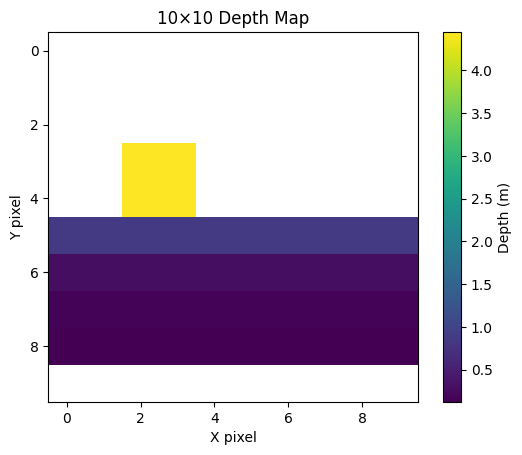

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Paste your raw data string exactly as it appears between the quotes:
raw = (
    "\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\022U\216@\304[\216@\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\022U\216@\304[\216@\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\000\000\200\177\027\005]?\032\005]?\036\005]?!\005]?$\005]?(\005]?-\005]?/\005]?1\005]?5\005]?\001\254\223>\003\254\223>\003\254\223>\004\254\223>\004\254\223>\005\254\223>\006\254\223>\007\254\223>\006\254\223>\007\254\223>\330H1>\331H1>\331H1>\333H1>\333H1>\333H1>\334H1>\334H1>\335H1>\335H1>\306O\375=\306O\375=\310O\375=\310O\375=\310O\375=\310O\375=\310O\375=\311O\375=\310O\375=\312O\375=\000\000\200\377\000\000\200\377\000\000\200\377\000\000\200\377\000\000\200\377\000\000\200\377\000\000\200\377\000\000\200\377\000\000\200\377\000\000\200\377"
)

# 2. Convert that Python string into bytes (latin-1 maps codepoints 0–255 straight to bytes)
b = raw.encode('latin-1')

# 3. Interpret it as float32 and reshape to 10×10
depth = np.frombuffer(b, dtype=np.float32).reshape((10, 10))

# 4. Plot it
plt.imshow(depth)
plt.colorbar(label='Depth (m)')
plt.title('10×10 Depth Map')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.show()


In [1]:
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import Image
import json
import os

class FullDepthJsonDumper(Node):
    def __init__(self):
        super().__init__('full_json_dumper')
        self.sub = self.create_subscription(
            Image,
            '/rgbd_camera/depth_image',
            self.cb,
            10
        )
        self.count = 0
        self.save_dir = os.path.expanduser("~/saved_depth_json")
        os.makedirs(self.save_dir, exist_ok=True)

    def cb(self, msg: Image):
        data_dict = {
            "header": {
                "stamp": {
                    "sec": msg.header.stamp.sec,
                    "nanosec": msg.header.stamp.nanosec
                },
                "frame_id": msg.header.frame_id
            },
            "height": msg.height,
            "width": msg.width,
            "encoding": msg.encoding,
            "is_bigendian": msg.is_bigendian,
            "step": msg.step,
            "data": list(msg.data)  # raw bytes to list of ints
        }

        file_path = os.path.join(self.save_dir, f"depth_msg_{self.count:04d}.json")
        with open(file_path, 'w') as f:
            json.dump(data_dict, f, indent=2)

        self.get_logger().info(f"Saved: {file_path}")
        self.count += 1

def main(args=None):
    rclpy.init(args=args)
    node = FullDepthJsonDumper()
    try:
        rclpy.spin(node)
    except KeyboardInterrupt:
        pass
    finally:
        node.destroy_node()
        rclpy.shutdown()

if __name__ == '__main__':
    main()


[INFO] [1749479480.253757259] [full_json_dumper]: Saved: /home/parth/saved_depth_json/depth_msg_0000.json
[INFO] [1749479480.261239542] [full_json_dumper]: Saved: /home/parth/saved_depth_json/depth_msg_0001.json
[INFO] [1749479480.266531236] [full_json_dumper]: Saved: /home/parth/saved_depth_json/depth_msg_0002.json
[INFO] [1749479480.286378102] [full_json_dumper]: Saved: /home/parth/saved_depth_json/depth_msg_0003.json
[INFO] [1749479480.325753228] [full_json_dumper]: Saved: /home/parth/saved_depth_json/depth_msg_0004.json
[INFO] [1749479480.365286844] [full_json_dumper]: Saved: /home/parth/saved_depth_json/depth_msg_0005.json
[INFO] [1749479480.412903278] [full_json_dumper]: Saved: /home/parth/saved_depth_json/depth_msg_0006.json
[INFO] [1749479480.446519297] [full_json_dumper]: Saved: /home/parth/saved_depth_json/depth_msg_0007.json
[INFO] [1749479480.483408663] [full_json_dumper]: Saved: /home/parth/saved_depth_json/depth_msg_0008.json
[INFO] [1749479480.525966251] [full_json_dumpe

RCLError: failed to shutdown: rcl_shutdown already called on the given context, at ./src/rcl/init.c:241

In [ ]:
import numpy as np
import cv2
import os

# Path to one of your saved depth .npy files
file_path = "/home/parth/saved_depth_images/depth_0000.npy"

# Load the NumPy array
depth_array = np.load(file_path)

# Print shape and min/max
print(f"Shape: {depth_array.shape}, dtype: {depth_array.dtype}")
print(f"Min: {np.nanmin(depth_array)}, Max: {np.nanmax(depth_array)}")

# Normalize and visualize
norm_img = cv2.normalize(depth_array, None, 0, 255, cv2.NORM_MINMAX)
norm_img = np.uint8(norm_img)
color_map = cv2.applyColorMap(norm_img, cv2.COLORMAP_JET)

cv2.imshow("Loaded Depth View", color_map)
cv2.waitKey(0)
cv2.destroyAllWindows()


Shape: (10, 10), dtype: float32
Min: -inf, Max: inf


/tmp/ipykernel_64004/3152003249.py:17: RuntimeWarning: invalid value encountered in cast
  norm_img = np.uint8(norm_img)


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import struct

# Load the JSON data (paste or load from file)
with open('depth_msg.json', 'r') as f:
    msg = json.load(f)

# Extract metadata
height = msg['height']
width = msg['width']
step = msg['step']
data = msg['data']

# Convert byte list to actual float32 values
raw_bytes = bytes(data)
depth_array = np.frombuffer(raw_bytes, dtype=np.float32).reshape((height, width))

# Replace inf or big values with NaN for safety
depth_array = np.where((depth_array > 1e6) | (depth_array <= 0), np.nan, depth_array)

# 🔍 Show min/max range
print(f"Depth min: {np.nanmin(depth_array):.4f}, max: {np.nanmax(depth_array):.4f}")

# 📈 Visualization
plt.imshow(depth_array, cmap='plasma')
plt.colorbar(label='Depth (m)')
plt.title('Depth Image from JSON')
plt.show()


/home/parth/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


FileNotFoundError: [Errno 2] No such file or directory: 'depth_msg.json'

In [ ]:
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import Image
from cv_bridge import CvBridge
import numpy as np
import cv2
import os

class DepthImageSaver(Node):
    def __init__(self):
        super().__init__('image_saver')
        self.subscription = self.create_subscription(
            Image,
            '/depth_camera',
            self.listener_callback,
            10
        )
        self.bridge = CvBridge()
        self.img_count = 0
        self.save_dir = os.path.expanduser("~/saved_deph_images")
        os.makedirs(self.save_dir, exist_ok=True)

    def listener_callback(self, msg):
        self.get_logger().info("Callback triggered!")
        try:
            # Convert ROS Image msg to cv2 image (float32 depth)
            cv_image = self.bridge.imgmsg_to_cv2(msg, desired_encoding='passthrough')
            self.get_logger().info(f"Depth min: {np.nanmin(cv_image)}, max: {np.nanmax(cv_image)}")

            # Save as CSV
            csv_path = os.path.join(self.save_dir, f"depthr_{self.img_count:04d}.csv")
            np.savetxt(csv_path, cv_image, delimiter=',', fmt='%.6f')
            self.get_logger().info(f"Saved CSV: {csv_path}")

            # Normalize for visualization (0-255)
            norm_img = cv2.normalize(cv_image, None, 0, 255, cv2.NORM_MINMAX)
            norm_img = np.uint8(norm_img)
            color_map = cv2.applyColorMap(norm_img, cv2.COLORMAP_JET)

            # Show the depth image colored
            cv2.imshow("Depth View", color_map)
            cv2.waitKey(1)

            self.img_count += 1

        except Exception as e:
            self.get_logger().error(f"Error converting image: {e}")

def main(args=None):
    rclpy.init(args=args)
    node = DepthImageSaver()
    try:
        rclpy.spin(node)
    except KeyboardInterrupt:
        pass
    finally:
        node.destroy_node()
        rclpy.shutdown()
        cv2.destroyAllWindows()

if __name__ == '__main__':
    main()


[INFO] [1749483635.959459258] [image_saver]: Callback triggered!
[INFO] [1749483635.966248926] [image_saver]: Depth min: 0.44783085584640503, max: inf
[INFO] [1749483636.028565429] [image_saver]: Saved CSV: /home/parth/saved_depth_images/depthr_0000.csv
/tmp/ipykernel_12784/1909616489.py:37: RuntimeWarning: invalid value encountered in cast
  norm_img = np.uint8(norm_img)
[INFO] [1749483636.645411326] [image_saver]: Callback triggered!
[INFO] [1749483636.650001021] [image_saver]: Depth min: 0.447843998670578, max: inf
[INFO] [1749483636.708855315] [image_saver]: Saved CSV: /home/parth/saved_depth_images/depthr_0001.csv
[INFO] [1749483636.722499001] [image_saver]: Callback triggered!
[INFO] [1749483636.726284990] [image_saver]: Depth min: 0.447843998670578, max: inf
[INFO] [1749483636.782522996] [image_saver]: Saved CSV: /home/parth/saved_depth_images/depthr_0002.csv
[INFO] [1749483636.791585021] [image_saver]: Callback triggered!
[INFO] [1749483636.797387217] [image_saver]: Depth min: 

RCLError: failed to shutdown: rcl_shutdown already called on the given context, at ./src/rcl/init.c:241

/home/parth/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


RCLError: failed to shutdown: rcl_shutdown already called on the given context, at ./src/rcl/init.c:241

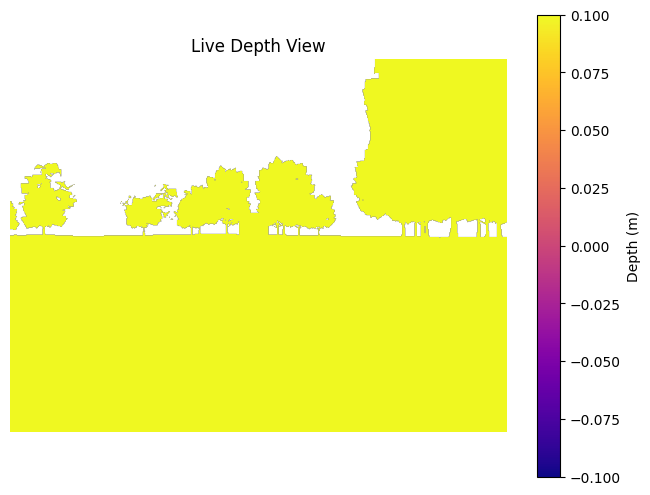

In [1]:
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import Image
from cv_bridge import CvBridge
import numpy as np
import matplotlib.pyplot as plt

class LiveDepthPlot(Node):
    def __init__(self):
        super().__init__('live_depth_plot')
        self.bridge = CvBridge()

        # Set up matplotlib for interactive plotting
        plt.ion()
        self.fig, self.ax = plt.subplots(figsize=(8, 6))
        self.im = None  # placeholder for the image handle
        self.cbar = None

        # Subscribe to the depth camera topic
        self.sub = self.create_subscription(
            Image,
            '/depth_camera',
            self.depth_callback,
            5
        )

    def depth_callback(self, msg: Image):
        # Convert ROS Image → NumPy array
        depth = self.bridge.imgmsg_to_cv2(msg, desired_encoding='passthrough')

        # Clean inf/nan

        # First time: create the image plot
        if self.im is None:
            self.im = self.ax.imshow(depth, cmap='plasma')
            self.cbar = self.fig.colorbar(self.im, ax=self.ax, label='Depth (m)')
            self.ax.set_title('Live Depth View')
            self.ax.axis('off')
        else:
            # Update data
            self.im.set_data(depth)
            # Rescale color limits if values changed significantly
            self.im.set_clim(vmin=np.min(depth), vmax=np.max(depth))

        # Draw and flush events
        self.fig.canvas.draw()
        self.fig.canvas.flush_events()

def main(args=None):
    rclpy.init(args=args)
    node = LiveDepthPlot()
    try:
        rclpy.spin(node)
    except KeyboardInterrupt:
        pass
    finally:
        node.destroy_node()
        rclpy.shutdown()
        plt.ioff()
        plt.close(node.fig)

if __name__ == '__main__':
    main()
